# LSPE-Strip Data Analysis Guide

This notebook provides a practical guide to the functions implemented in `stripfunctions.py`, which I developed during my Master's thesis work on LSPE-Strip data analysis, starting from the tools and methods provided by the `striptease` package.

The goal is to demonstrate how to:
- Load scientific and housekeeping data from the LSPE-Strip database
- Process DEM and PWR signals
- Compute noise spectra
- Detect and remove periodic spikes
- Monitor housekeeping and thermal parameters
- Save results and generate plots

All functions in `stripfunctions.py` are fully documented in the source file, including a description of what they do and their input parameters.

In [1]:
from importlib import reload
import stripfunctions as sf
reload(sf)

/home/riccardo/.local/lib/python3.10/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


<module 'stripfunctions' from '/mnt/c/Users/guido/striptease/stripfunctions.py'>

## 1. Database Initialization

All LSPE-Strip data are stored in HDF5 files, which can be organized into a database structure.
The database is accessed through the `DataStorage` class from the `striptease` package.
This makes it possible to analyze multiple files together, or select specific time intervals that may span across different files, instead of working on a single file at a time.


The function `database` initializes a `DataStorage` object pointing to the directory containing the data files.
This object is required for all subsequent data loading operations.


Before loading any data, it is useful to inspect the available files and their time coverage.
The function `list_of_files`prints the file name and the corresponding time interval in Modified Julian Date (MJD).
This allows the user to identify the correct MJD range to use for data extraction.


In [2]:
# Database containing the data files
ds_path = "/mnt/c/Users/guido/striptease/file_HDF5"
ds = sf.database(ds_path)

# List of files in the database with their MJD time acquisition range
sf.list_of_files(ds)

file 1: /mnt/c/Users/guido/striptease/file_HDF5/2025_01_02_07-06-04.h5
mjd_range: (60677.29588429538, 60677.46271817129)

file 2: /mnt/c/Users/guido/striptease/file_HDF5/2025_02_06_17-00-01.h5
mjd_range: (60712.70837623051, 60712.875221180555)

file 3: /mnt/c/Users/guido/striptease/file_HDF5/2026_02_20_06-41-19.h5
mjd_range: (61091.278688541664, 61091.44535555555)

file 4: /mnt/c/Users/guido/striptease/file_HDF5/2026_03_02_05-05-49.h5
mjd_range: (61101.21237409299, 61101.379045023146)



In [3]:
# Example MJD time ranges used during the data analysis
cryo_1 = (60677.29935743095, 60677.45924503572)
cryo_2 = (60740.8996805311, 60741.05959838424)
warm = (60774.00918518056, 60774.16890718056)
THx100 = (60774.7058269868, 60774.8655489838)
PS5656 = (60776.61357015776, 60776.68406910741)
PS6556 = (60776.69109235483, 60776.73497016117)
PS6666 = (60776.74197413248, 60776.90170732043)
HKx10 = (60779.70051828713, 60779.86025141776)
Y_alone = (60780.595987966735, 60780.61842526378)
G_alone = (60780.66912017106, 60780.67361713993)
V_alone = (60780.687266408, 60780.692549870684)
I_alone = (60780.70389252038, 60780.712707561746)
R_alone = (60780.72463591283, 60780.72778963765)
disc_all = (60839.57579884259, 60839.617465856485)

yfactor_1 = (60712.754574559, 60712.788404462335)
yfactor_2 = (60740.77716863732, 60740.79870131827)

After selecting the time range of interest, it is possible to inspect the tags associated with that interval.

The function `list_of_tags` returns the tags recorded during the acquisition (if present), including their start and end times in MJD, which are useful to identify specific phases of the measurement.

In [4]:
# MJD time range to consider
mjd_range = cryo_1

# List of tags in the selected MJD time range
tags = sf.list_of_tags(ds, mjd_range) 

## 2. Scientific Data

In the HDF5 files, the acquired raw scientific signals can be either:

- DEM (demodulated signals)
- PWR (total power signals)

The function `scientific_output` is used to extract these raw time-ordered data from the database.

In [5]:
# Type of data to consider ("DEM", "PWR")
data_type = "DEM"

# Polarimeters ["R0", "R1", "R2", ...] or entire boards ["R", "V", "G", "B", "Y", "O", "I"] to consider 
polarimeters = ["Y3"]

# Detectors to consider ["Q1", "Q2", "U1", "U2"]
detectors = ["U2"]

# Save path
save_path = "/mnt/c/Users/guido/striptease/LSPE_Strip/TESI"

However, both DEM and PWR signals require additional processing before being used for analysis, in particular DEM data must be double-demodulated.
This post-processing is handled automatically by the function `scientific_data`, which applies the appropriate operation depending on the selected data type and ensures proper time alignment between samples.

After selecting the desired polarimeters and detectors, it is therefore sufficient to call `scientific_data` directly to obtain the final time-ordered data (TOD), since this function internally calls `scientific_output` and performs all the required processing steps.
The resulting data follow a consistent hierarchical structure:

    {'polarimeter': {'detector': {'time', 'data'}}}

In [6]:
sci_data = sf.scientific_data(ds, mjd_range, data_type, polarimeters, detectors)

Loading data: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.48s/it]


The processed time-ordered data can be visualized using the function `plot_data`.

By setting `save=True` and specifying a directory path, the generated figures are automatically stored in the chosen directory.

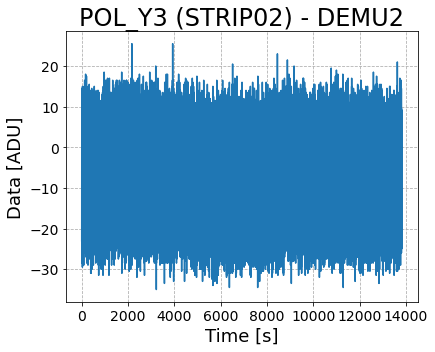

In [7]:
sf.plot_data(sci_data, mjd_range, save_path, save=False)

## 3. Spectral Analysis

The noise spectrum of the processed time-ordered data can be computed using the function `spectrum_data`.

This function calculates the power spectral density (PSD) starting from the scientific data previously obtained with `scientific_data`.
The resulting spectra follow the hierarchical structure:

    {'polarimeter': {'detector': {'frequency', 'spectrum'}}}

In [8]:
spec = sf.spectrum_data(sci_data)

The spectra can be visualized using `plot_spec`.
As for time-domain plots, by setting `save=True` and specifying a directory path, the figures are automatically saved in the chosen directory.

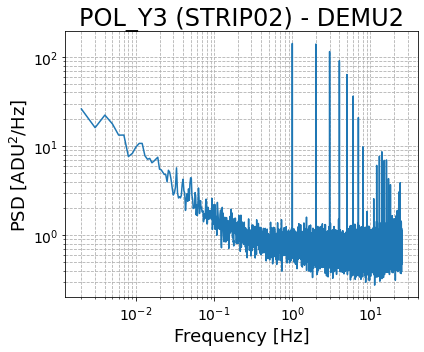

In [9]:
sf.plot_spec(spec, mjd_range, save_path, save=False)

Sharp narrow peaks may appear in the noise spectrum due to periodic electronic or instrumental disturbances.

The function `find_spikes` identifies these features directly in the frequency domain by comparing the local spectral amplitude to the surrounding trend.

The detected spike frequencies are returned in a dictionary with the structure:

    {'polarimeter': {'detector': [frequencies]}}

In addition, the frequencies are automatically saved to a JSON file in the specified directory, allowing them to be stored and reused for further analysis.

In [10]:
spikes = sf.find_spikes(spec, save_path)
spikes

JSON file saved to /mnt/c/Users/guido/striptease/LSPE_Strip/TESI/spikes.json


{'Y3': {'DEMU2': [0.9999800004006825,
   1.999960000801365,
   2.9999400012020474,
   3.99992000160273,
   4.999900002003412,
   5.999880002404095,
   6.999860002804777,
   7.99984000320546,
   11.99976000480819,
   12.999740005208873,
   13.999720005609554,
   14.999700006010237,
   15.99968000641092]}}

After identifying periodic disturbances in the spectrum, it is possible to remove them directly in the time domain.

The function `remove_spikes` reconstructs the repeating spike pattern over fixed-duration windows and subtracts it from the original time-ordered data.
The duration of the window is selected by the user through the `window_sec` parameter, depending on the expected periodicity of the disturbance (for example, 1 second for spikes around 1 Hz).

The cleaned data maintain the same hierarchical structure as the original scientific data:

    {'polarimeter': {'detector': {'time', 'data'}}}

In [11]:
clean = sf.remove_spikes(sci_data, window_sec=1)

The spectrum can then be recomputed using the function `spectrum_data` to verify the suppression of the identified spikes.

A more detailed description of the spike analysis procedure is provided in the dedicated Jupyter notebook.

In [12]:
spec_clean = sf.spectrum_data(clean)

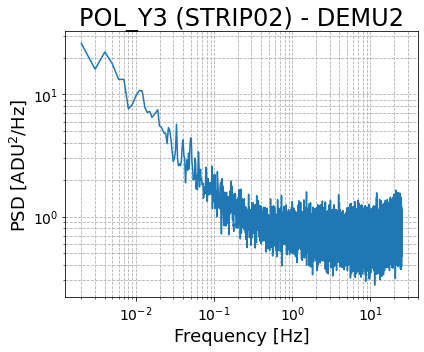

In [13]:
sf.plot_spec(spec_clean, mjd_range, save_path, save=False)

## 4. Housekeeping and Thermal Data 

In addition to scientific signals, the HDF5 files contain housekeeping parameters and thermal sensor data, which are useful for monitoring instrument stability and operating conditions.

Housekeeping data (e.g. voltages, currents, bias parameters) can be extracted using the function `housekeeping_data`.
The function automatically identifies the correct group in the HDF5 structure (BIAS or DAQ) where the requested parameter is stored, so the user does not need to manually specify it.

Thermal sensor measurements can be extracted using `thermal_data`, either in calibrated units (Kelvin) or as raw ADU values, by specifying the name of the desired sensor.

As for scientific data, a specific MJD time range must be selected before loading the data.  

In [14]:
# Turning on/off the Bias Board powering polarimeters (group: 'BIAS').

# Provides voltage to the Bias Board powering polarimeters.
POL_PWR = ["POL_PWR"]

# Provides the voltage reference to the Bias Board powering polarimeters.
DAC_REF = ["DAC_REF"]

In [15]:
# LNA housekeeping parameters (group: 'BIAS').

# Operative modes to set the LNA biases: 5 (open loop), 3 (closed loop).
POL_MODE = ["POL_MODE"]

# Gate and drain voltages [ADU], drain currents [ADU] set for LNAs.
VG_SET = ["VG0_SET","VG1_SET","VG2_SET","VG3_SET","VG4_SET","VG5_SET","VG4A_SET","VG5A_SET"]
VD_SET = ["VD0_SET","VD1_SET","VD2_SET","VD3_SET","VD4_SET","VD5_SET"]
ID_SET = ["ID0_SET","ID1_SET","ID2_SET","ID3_SET","ID4_SET","ID5_SET"]


# Gate and drain voltages [mV], gate and drain currents [µA] for LNAs in physical units.
VG_HK = ["VG0_HK","VG1_HK","VG2_HK","VG3_HK","VG4_HK","VG5_HK","VG4A_HK","VG5A_HK"]
VD_HK = ["VD0_HK","VD1_HK","VD2_HK","VD3_HK","VD4_HK","VD5_HK"]
IG_HK = ["IG0_HK","IG1_HK","IG2_HK","IG3_HK","IG4_HK","IG5_HK"]
ID_HK = ["ID0_HK","ID1_HK","ID2_HK","ID3_HK","ID4_HK","ID5_HK"]

In [16]:
# Phase switches housekeeping parameters (group: 'BIAS').

# Operating status for phase switch: 5 (forward), 6 (reverse), 7 (switching).
PIN_CON = ["PIN0_CON", "PIN1_CON", "PIN2_CON", "PIN3_CON"]

# Voltages [ADU] and currents [ADU] set for phase switch.
VPIN_SET = ["VPIN0_SET","VPIN1_SET","VPIN2_SET","VPIN3_SET"]
IPIN_SET = ["IPIN0_SET","IPIN1_SET","IPIN2_SET","IPIN3_SET"]

# Voltages [mV] and currents [µA] for phase switch in physical units.
VPIN_HK = ["VPIN0_HK","VPIN1_HK","VPIN2_HK","VPIN3_HK"]
IPIN_HK = ["IPIN0_HK","IPIN1_HK","IPIN2_HK","IPIN3_HK"]

In [17]:
# Detectors housekeeping parameters (group: 'DAQ').

DAC_EN = ["DAC_EN"]

# Detector gain status: 0 (fixed value), 1 (configurable value).
GAIN_EN = ["GAIN_EN"]

# Detector biases [ADU]: 1000 (cryo), 0 (warm).
DET_BIAS = ["DET0_BIAS", "DET1_BIAS", "DET2_BIAS", "DET3_BIAS"]

# Detector gain [ADU]: 2281 (if GAIN_EN = 0)
DET_GAIN = ["DET0_GAIN", "DET1_GAIN", "DET2_GAIN", "DET3_GAIN"]

# Detector offset [ADU]
DET_OFFS = ["DET0_OFFS", "DET1_OFFS", "DET2_OFFS", "DET3_OFFS"]

In [18]:
# Thermal sensors

STATUS_0 = ["TS-CX2-Module-V", "TS-CX4-Module-G", "TS-CX6-Module-O", "TS-CX10-Frame-120", "TS-CX12-Pol-W", 
            "TS-CX14-Pol-Qy", "TS-CX16-Filter", "EX-CX18-SpareCx", "TS-DT3-Shield-Base", "TS-DT6-Frame-South",
            "TS-SP1-SpareDT", "TS-SP2-L-Support"]

STATUS_1 = ["TS-CX1-Module-R", "TS-CX3-Module-B", "TS-CX5-Module-Y", "TS-CX7-Module-I", "TS-CX8-Frame-0", 
            "TS-CX9-Frame-60", "TS-CX11-Frame-North", "TS-CX13-Pol-Qx", "TS-CX15-IF-Frame-0", "TS-CX17-Wheel-Center",
            "EX-DT2-SpareDT", "TS-DT5-Shield-Side"]

It is often useful to compute these values over multiple time ranges, corresponding to different acquisition phases (e.g. ['cryo_1', 'cryo_2', ...]).  
The functions:

- `save_housekeeping_data`
- `save_thermal_data`

automatically call the corresponding data-loading functions internally, extract the selected parameters, compute average values over a list of MJD intervals, and save the results into an Excel file.
Each time interval is written to a separate sheet, making it easy to compare different acquisition phases and operating conditions.

In [19]:
mjd_ranges = [cryo_1, yfactor_1]

parameters = VD_HK+VPIN_HK+IPIN_HK+ID_HK+DET_BIAS+DET_OFFS+DET_GAIN+GAIN_EN
sensor_name = STATUS_0+STATUS_1

In [20]:
sf.save_housekeeping_data(ds, mjd_ranges, parameters, polarimeters, save_path)

Loading data: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.08it/s]

Excel file saved to /mnt/c/Users/guido/striptease/LSPE_Strip/TESI/housekeeping_data.xlsx


In [21]:
sf.save_thermal_data(ds, mjd_ranges, sensor_name, save_path)

Excel file saved to /mnt/c/Users/guido/striptease/LSPE_Strip/TESI/thermal_data.xlsx
